In [2]:
import torch
from matplotlib import pyplot as plt
from matplotlib_inline import backend_inline

# 노트북 출력 영역에 그래프를 선명한 PNG로 표시한다.
backend_inline.set_matplotlib_formats("png")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["figure.dpi"] = 120

In [3]:
def f(x):
    """원래 함수 f(x) = 3x² - 4x를 계산한다."""
    return 3 * x**2 - 4 * x


def derivative_f(x):
    """해석적으로 구한 도함수 f'(x) = 6x - 4를 계산한다."""
    return 6 * x - 4

In [4]:
# 그래프에 사용할 100개의 x좌표와 각 함수값을 계산한다.
x_values = torch.linspace(0.0, 3.0, 100, dtype=torch.float64)
function_values = f(x_values)

# x₀=1에서의 함수값과 기울기를 접선 공식에 대입한다.
x0 = torch.tensor(1.0, dtype=torch.float64)
function_value_at_x0 = f(x0)
slope_at_x0 = derivative_f(x0)
tangent_values = function_value_at_x0 + slope_at_x0 * (x_values - x0)

print("x_values shape:", x_values.shape)
print("f(1):", function_value_at_x0.item())
print("f'(1):", slope_at_x0.item())

assert function_values.shape == x_values.shape
assert tangent_values.shape == x_values.shape
assert torch.isclose(function_value_at_x0, torch.tensor(-1.0, dtype=torch.float64))
assert torch.isclose(slope_at_x0, torch.tensor(2.0, dtype=torch.float64))

x_values shape: torch.Size([100])
f(1): -1.0
f'(1): 2.0


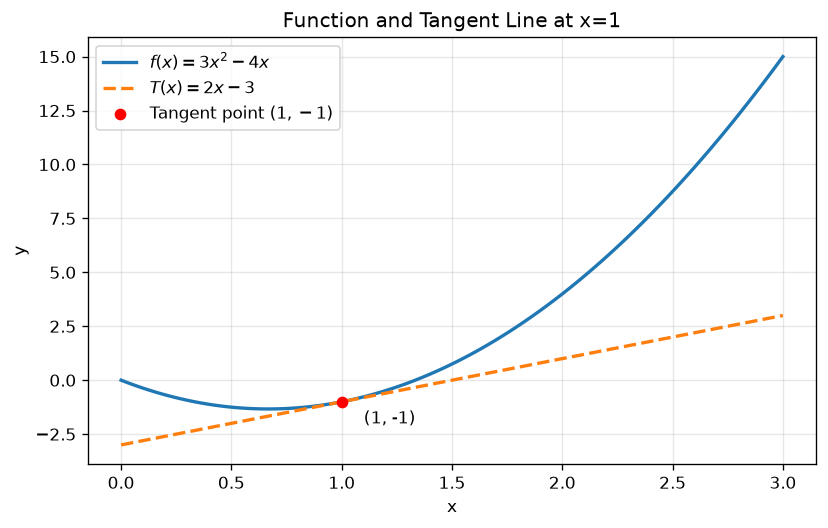

In [5]:
# matplotlib이 처리할 수 있도록 tensor를 CPU의 NumPy 배열로 변환한다.
x_numpy = x_values.detach().cpu().numpy()
function_numpy = function_values.detach().cpu().numpy()
tangent_numpy = tangent_values.detach().cpu().numpy()

figure, axes = plt.subplots()
axes.plot(x_numpy, function_numpy, linewidth=2, label=r"$f(x)=3x^2-4x$")
axes.plot(x_numpy, tangent_numpy, "--", linewidth=2, label=r"$T(x)=2x-3$")

# 함수와 접선이 만나는 접점 (1, -1)을 빨간색으로 표시한다.
axes.scatter(1.0, -1.0, color="red", zorder=3, label=r"Tangent point $(1,-1)$")
axes.annotate("(1, -1)", (1.0, -1.0), xytext=(1.1, -2.0))

axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_title("Function and Tangent Line at x=1")
axes.grid(True, alpha=0.3)
axes.legend()
figure.tight_layout()
plt.show()

In [6]:
# 접선은 기준점 x₀에서 반드시 원래 함수와 같은 값을 가져야 한다.
tangent_value_at_x0 = function_value_at_x0 + slope_at_x0 * (x0 - x0)

print("f(x₀):", function_value_at_x0.item())
print("T(x₀):", tangent_value_at_x0.item())

assert torch.isclose(tangent_value_at_x0, function_value_at_x0)

f(x₀): -1.0
T(x₀): -1.0
